<a href="https://colab.research.google.com/github/SilasDetering/SilasBA/blob/main/Silas_BA_Graphen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

# 1.0 Raw RSSI and Kalmanfiltered RSSI für bestimmte Distanz

In [ ]:
# Datei hochladen
uploaded = files.upload()
file_name = next(iter(uploaded))

# Excel-Datei einlesen (angenommen, die erste Zeile enthält die Spaltennamen)
df = pd.read_excel(file_name)

Saving messung1-oneMeterOlny.xlsx to messung1-oneMeterOlny (1).xlsx


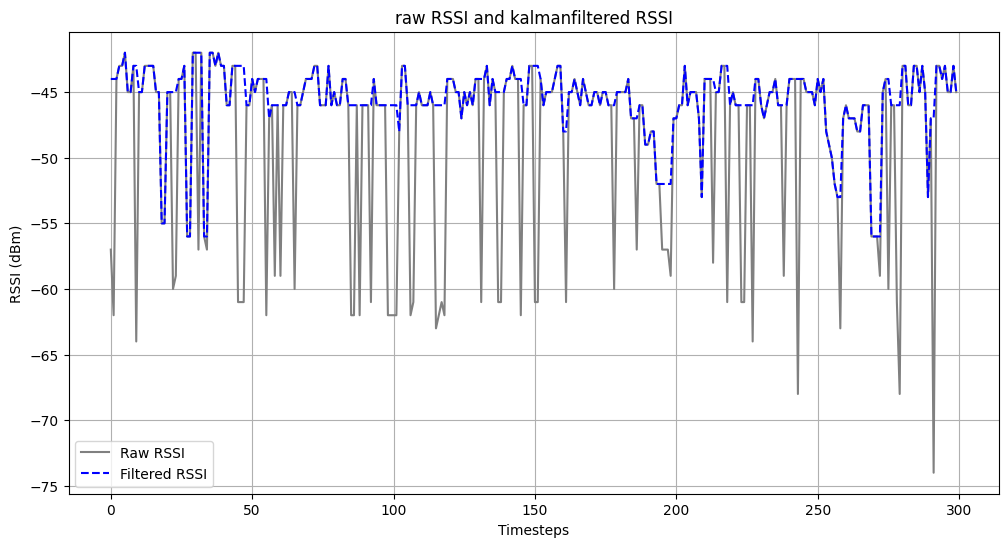

In [ ]:
# Sicherstellen, dass die Spalten korrekt benannt sind (falls notwendig)
df.columns = ['RSSI', 'Filtered', 'Distance']

# Reale Distanz als konstante festlegen
real_distance = 0.5

# Graphen erstellen
plt.figure(figsize=(12, 6))

# Plot für RSSI
plt.plot(df.index, df['RSSI'], label='Raw RSSI', linestyle='-', color='gray')

# Plot für gefilterten RSSI
plt.plot(df.index, df['Filtered'], label='Filtered RSSI', linestyle='--', color='blue')

plt.ylabel('RSSI (dBm)')
plt.xlabel('Timesteps')

# Zweite Y-Achse für die Distanz
# dist_ax = plt.gca().twinx()
# dist_ax.plot(df.index, df['Distance'], label='Distance', color='green', linestyle='--')

# Reale Distanz als konstante Linie hinzufügen
# dist_ax.axhline(y=real_distance, color='red', linestyle=':', label='Real Distance')

# Achsentitel und Beschriftungen setzen
# dist_ax.set_ylabel('Distance (m)')

plt.legend()
plt.grid()
plt.title('raw RSSI and kalmanfiltered RSSI')

plt.show()


# 1.1 Hig Fluctuation Filter für bestimmte Distanz

<ipython-input-26-b0d2bc63f666>:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Filtered'] = df['RSSI'].where(df['RSSI'] < upper_limit).fillna(method='ffill').fillna(method='bfill')
<ipython-input-26-b0d2bc63f666>:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Filtered'] = df['RSSI'].where(df['RSSI'] > lower_limit).fillna(method='ffill').fillna(method='bfill')


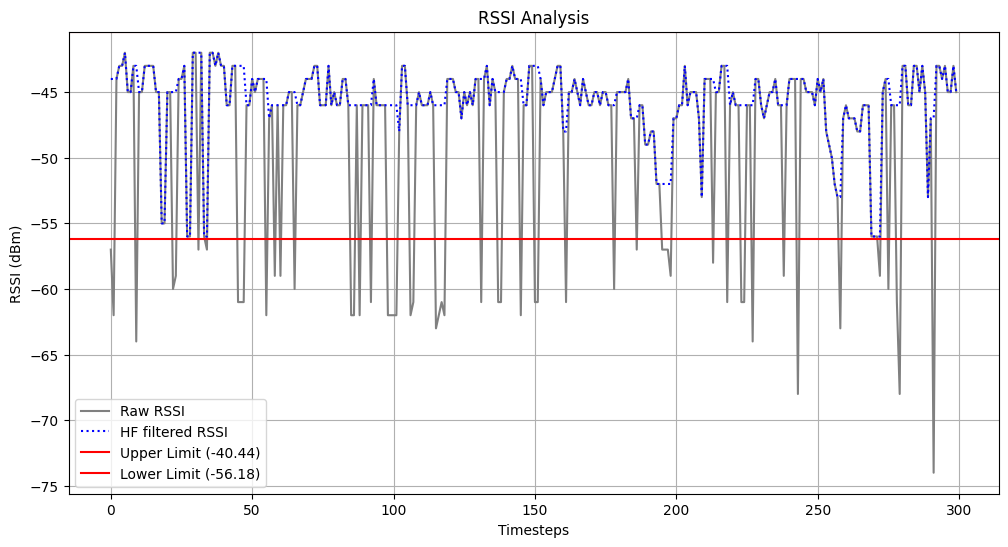

In [ ]:
# Sicherstellen, dass die Spalten korrekt benannt sind (falls notwendig)
df.columns = ['RSSI', 'Filtered', 'Distance']

# Berechnung des Mittelwerts und der Standardabweichung der RSSI-Werte
mean_rssi = df['RSSI'].mean()
std_rssi = df['RSSI'].std()

# Berechnung der Limits (Fluktuationsfilter)
upper_limit = mean_rssi + (1.2 * std_rssi)
lower_limit = mean_rssi - (1.2 * std_rssi)

# Filtern der RSSI-Werte, die das Upper Limit überschreiten
df['Filtered'] = df['RSSI'].where(df['RSSI'] < upper_limit).fillna(method='ffill').fillna(method='bfill')
df['Filtered'] = df['RSSI'].where(df['RSSI'] > lower_limit).fillna(method='ffill').fillna(method='bfill')

# Graphen erstellen
plt.figure(figsize=(12, 6))

# Plot für RSSI
plt.plot(df.index, df['RSSI'], label='Raw RSSI', linestyle='-', color='gray')

# Plot für gefilterten RSSI
plt.plot(df.index, df['Filtered'], label='HF filtered RSSI', linestyle=':', color='blue')

# Plot der Upper Limit und Lower Limit Linien
plt.axhline(y=upper_limit, color='red', linestyle='-', label=f'Upper Limit ({upper_limit:.2f})')
plt.axhline(y=lower_limit, color='red', linestyle='-', label=f'Lower Limit ({lower_limit:.2f})')

plt.ylabel('RSSI (dBm)')
plt.xlabel('Timesteps')

# Legenden anpassen
plt.legend()
plt.grid()
plt.title('RSSI Analysis')

plt.show()


# 2.0 RSSI ohne Filter für mehrere Distanzen
(Distance Path Loss n, m Parameter kalibrierung)

In [6]:
# Datei hochladen
uploaded = files.upload()
file_name = next(iter(uploaded))

# Excel-Datei einlesen
df = pd.read_excel(file_name, header=None)
df = df.replace(',', '.', regex=True)

Saving messung1-rssionly.xlsx to messung1-rssionly.xlsx


/usr/local/lib/python3.10/dist-packages/pandas/core/indexes/base.py:945: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*new_inputs, **kwargs)
<ipython-input-35-b8d81a71ac70>:23: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(rssi_model, mean_rssi_per_distance.index, mean_rssi_per_distance.values)


Optimierte Parameter: n = 1.00, a = 1.00


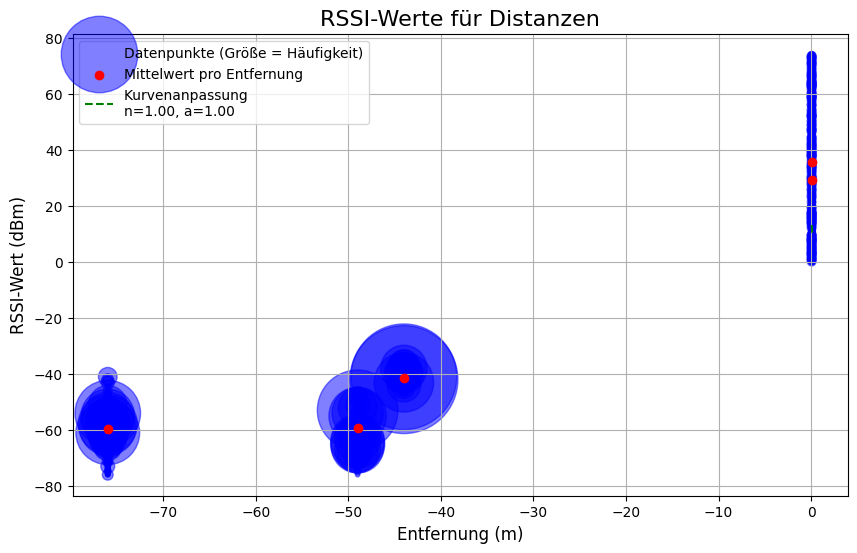

In [35]:
# Die erste Zeile als Entfernungen verwenden
distances = df.iloc[0, :]

# Die restlichen Zeilen als RSSI-Werte
rssi_values = df.iloc[1:, :]

# Daten ins Long-Format umwandeln
df_long = rssi_values.melt(var_name='distance_index', value_name='rssi')
df_long['distance'] = distances[df_long['distance_index']].values
df_long = df_long.drop(columns=['distance_index']).dropna().reset_index(drop=True)

# Häufigkeit der Datenpunkte berechnen
point_counts = df_long.groupby(['distance', 'rssi']).size().reset_index(name='count')

# Mittelwert der RSSI-Werte für jede Entfernung berechnen
mean_rssi_per_distance = df_long.groupby('distance')['rssi'].mean()

# Modellfunktion definieren
def rssi_model(distance, n, a):
    return -10 * n * np.log10(distance) + a

# Curve-Fit durchführen
popt, pcov = curve_fit(rssi_model, mean_rssi_per_distance.index, mean_rssi_per_distance.values)

# Optimierte Parameter
n, a = popt
print(f"Optimierte Parameter: n = {n:.2f}, a = {a:.2f}")

# Fit-Daten berechnen
fitted_rssi = rssi_model(mean_rssi_per_distance.index, n, a)

# Scatterplot erstellen
plt.figure(figsize=(10, 6))

# Datenpunkte mit Größen entsprechend ihrer Häufigkeit plotten
plt.scatter(point_counts['distance'], point_counts['rssi'],
            s=point_counts['count'] * 10,  # Größe proportional zur Häufigkeit
            alpha=0.5,
            label='Datenpunkte (Größe = Häufigkeit)',
            color='blue')

# Mittelwert als Punkte für jede Entfernung zeichnen
plt.scatter(mean_rssi_per_distance.index, mean_rssi_per_distance.values,
            color='red', label='Mittelwert pro Entfernung', zorder=5)

# Angepasste Kurve hinzufügen
plt.plot(mean_rssi_per_distance.index, fitted_rssi,
         color='green', linestyle='--',
         label=f'Kurvenanpassung \nn={n:.2f}, a={a:.2f}')

# Titel und Achsenbeschriftungen hinzufügen
plt.title("RSSI-Werte für Distanzen", fontsize=16)
plt.xlabel("Entfernung (m)", fontsize=12)
plt.ylabel("RSSI-Wert (dBm)", fontsize=12)

# Legende hinzufügen
plt.legend()

# Raster aktivieren
plt.grid(True)

# Plot anzeigen
plt.show()


# 2.1 RSSI mit Hard Fluctuation Filter für mehrere Distanzen
(Distance Path Loss n, m Parameter kalibrierung)

Optimierte Parameter: n = 0.94, a = -48.33


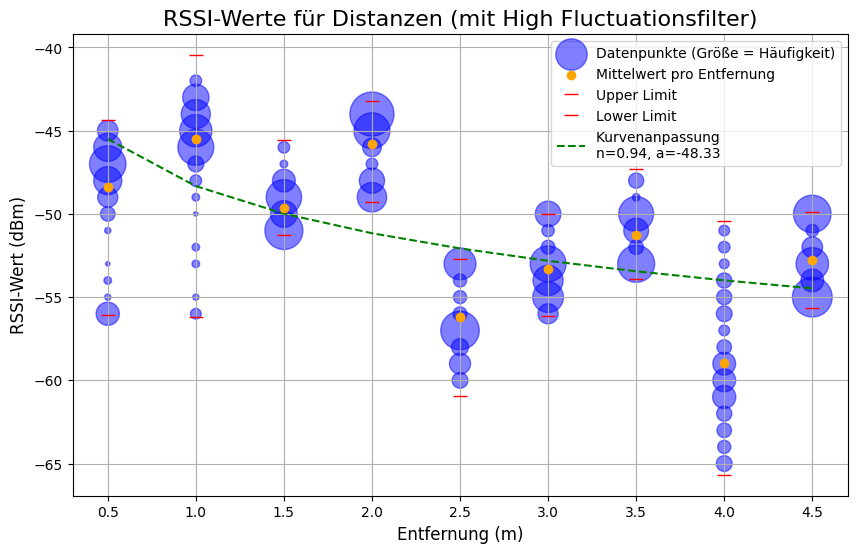

In [26]:
# Die erste Zeile als Entfernungen verwenden
distances = df.iloc[0, :]

# Die restlichen Zeilen als RSSI-Werte
rssi_values = df.iloc[1:, :]

# Daten ins Long-Format umwandeln
df_long = rssi_values.melt(var_name='distance_index', value_name='rssi')
df_long['distance'] = distances[df_long['distance_index']].values
df_long = df_long.drop(columns=['distance_index']).dropna().reset_index(drop=True)

# Mittelwert und Standardabweichung berechnen
mean_rssi_per_distance = df_long.groupby("distance")["rssi"].mean()
std_rssi_per_distance = df_long.groupby("distance")["rssi"].std()

# Fluktuationsfilter anwenden (Upper Limit)
upper_limit = mean_rssi_per_distance + (1.2 * std_rssi_per_distance)

# Fluktuationsfilter anwenden (Lower Limit)
lower_limit = mean_rssi_per_distance - (1.2 * std_rssi_per_distance)

# Filter data based on upper and lower limits
df_long_filtered = df_long[
    (df_long["rssi"] <= df_long["distance"].map(upper_limit)) &
    (df_long["rssi"] >= df_long["distance"].map(lower_limit))
]

# Neuen Mittelwert berechnen
mean_rssi_filtered = df_long_filtered.groupby("distance")["rssi"].mean()

# Häufigkeit der Datenpunkte berechnen
point_counts = df_long_filtered.groupby(['distance', 'rssi']).size().reset_index(name='count')

# Modellfunktion definieren
def rssi_model(distance, n, a):
    return -10 * n * np.log10(distance) + a

# Curve-Fit durchführen
popt, pcov = curve_fit(rssi_model, mean_rssi_filtered.index, mean_rssi_filtered.values)

# Optimierte Parameter
n, a = popt
print(f"Optimierte Parameter: n = {n:.2f}, a = {a:.2f}")

# Fit-Daten berechnen
fitted_rssi = rssi_model(mean_rssi_filtered.index, n, a)

# Scatterplot erstellen
plt.figure(figsize=(10, 6))

# Datenpunkte mit Größen entsprechend ihrer Häufigkeit plotten
plt.scatter(point_counts['distance'], point_counts['rssi'],
            s=point_counts['count'] * 10,  # Größe proportional zur Häufigkeit
            alpha=0.5,
            label='Datenpunkte (Größe = Häufigkeit)',
            color='blue')

# Mittelwert als Punkte für jede Entfernung zeichnen
plt.scatter(mean_rssi_filtered.index, mean_rssi_filtered.values,
            color='orange', label='Mittelwert pro Entfernung', zorder=5)

# Obergrenze einzeichnen
plt.plot(upper_limit.index, upper_limit.values,
            marker='_', linestyle='None', color='red', markersize=10, label='Upper Limit', zorder=5)

# Untergrenze einzeichnen
plt.plot(lower_limit.index, lower_limit.values,
            marker='_', linestyle='None', color='red', markersize=10, label='Lower Limit', zorder=5)

# Angepasste Kurve hinzufügen
plt.plot(mean_rssi_filtered.index, fitted_rssi,
         color='green', linestyle='--',
         label=f'Kurvenanpassung \nn={n:.2f}, a={a:.2f}')

# Titel und Achsenbeschriftungen hinzufügen
plt.title("RSSI-Werte für Distanzen (mit High Fluctuationsfilter)", fontsize=16)
plt.xlabel("Entfernung (m)", fontsize=12)
plt.ylabel("RSSI-Wert (dBm)", fontsize=12)

# Legende hinzufügen
plt.legend()

# Raster aktivieren
plt.grid(True)

# Plot anzeigen
plt.show()


# 3. Vergleich unterschiedliche RSSI Filter

In [27]:
# Datei hochladen
uploaded = files.upload()
file_name = next(iter(uploaded))

Saving messung2-2.xlsx to messung2-2 (1).xlsx


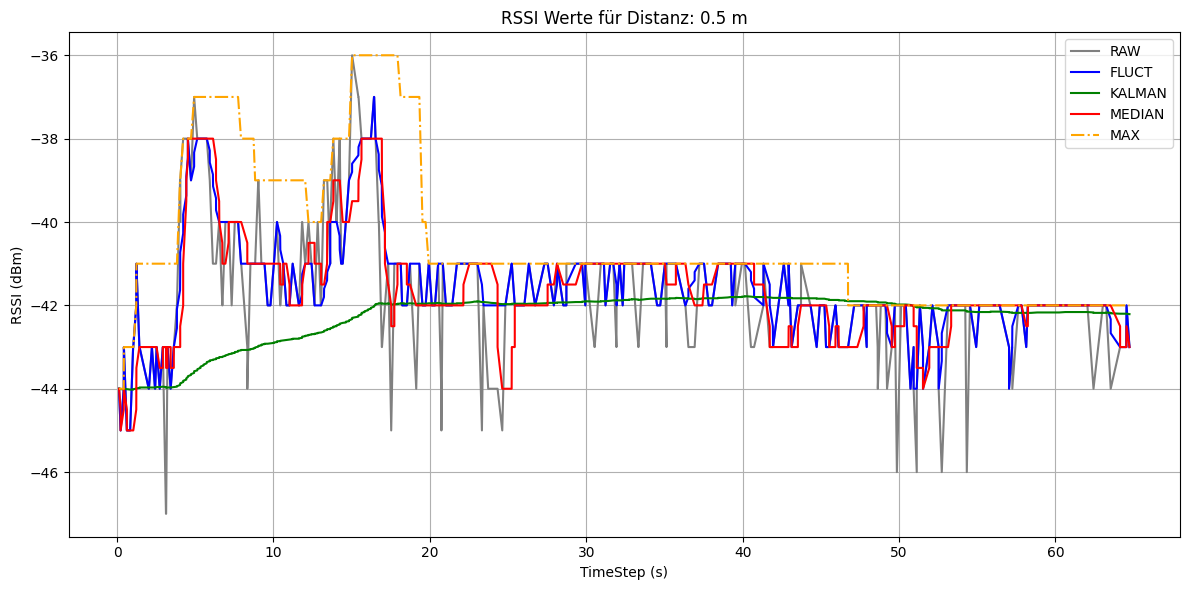

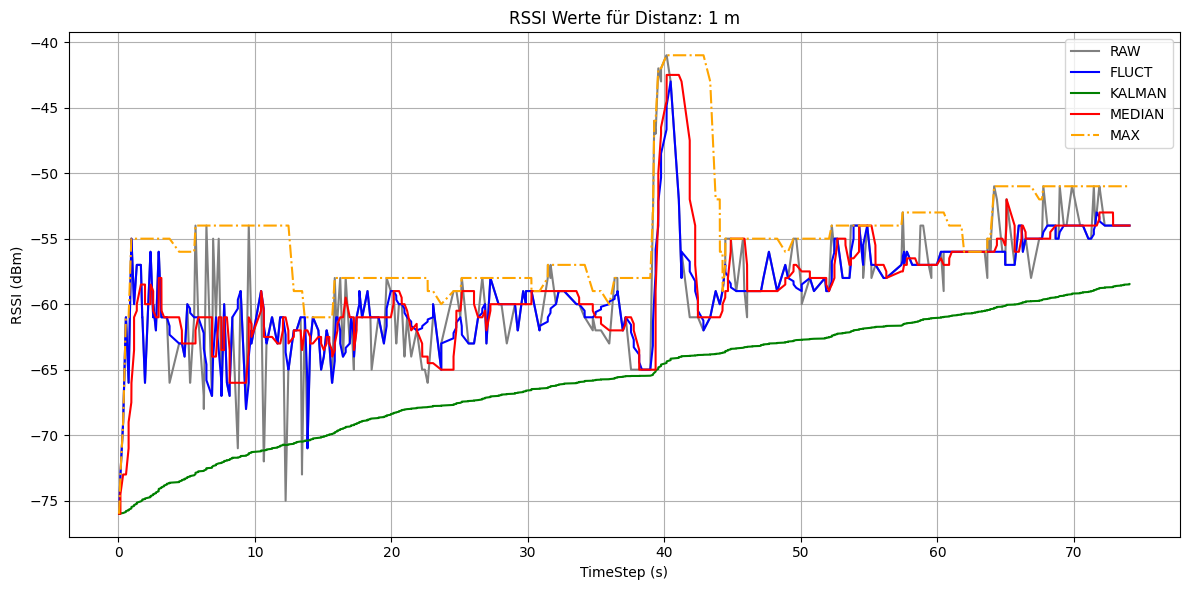

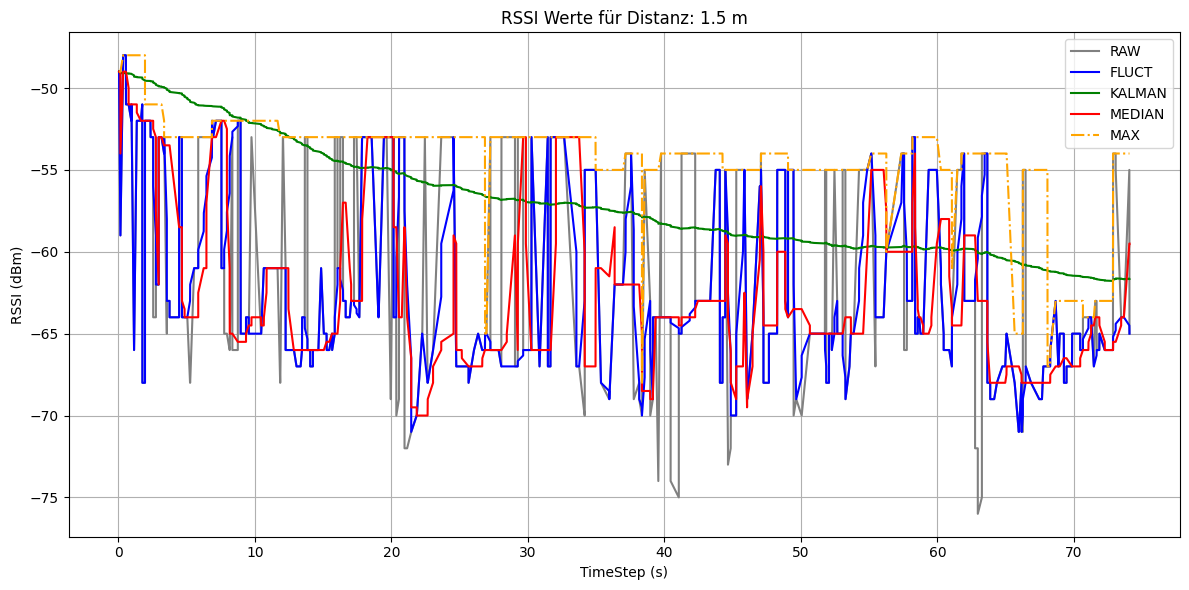

In [28]:
# Excel-Datei einlesen
df = pd.read_excel(file_name, header=1)  # Die zweite Zeile enthält die Spaltenüberschriften
distances = pd.read_excel(file_name, header=None).iloc[0].dropna().unique()  # Die erste Zeile enthält die Distanzen

# Jede Distanz separat verarbeiten
num_filters = 5  # Anzahl der Filter (RAW, FLUCT, KALMAN, MEDIAN, MAX)
for i, dist in enumerate(distances):
    # Spalten für die aktuelle Distanz extrahieren
    start_col = i * (num_filters + 1)  # Startspalte für diese Distanz
    cols = df.columns[start_col : start_col + (num_filters + 1)]  # Zeitsäule + Filterspalten

    # Sub-DataFrame erstellen
    dist_df = df[cols].rename(columns={
        cols[0]: 'TimeStep',
        cols[1]: 'RAW',
        cols[2]: 'FLUCT',
        cols[3]: 'KALMAN',
        cols[4]: 'MEDIAN',
        cols[5]: 'MAX'
    })

    # NaN-Werte interpolieren
    dist_df = dist_df.interpolate()

    # Graphen erstellen
    plt.figure(figsize=(12, 6))
    plt.plot(dist_df['TimeStep'], dist_df['RAW'], label='RAW', color='gray', linestyle='-')
    plt.plot(dist_df['TimeStep'], dist_df['FLUCT'], label='FLUCT', color='blue', linestyle='-')
    plt.plot(dist_df['TimeStep'], dist_df['KALMAN'], label='KALMAN', color='green', linestyle='-')
    plt.plot(dist_df['TimeStep'], dist_df['MEDIAN'], label='MEDIAN', color='red', linestyle='-')
    plt.plot(dist_df['TimeStep'], dist_df['MAX'], label='MAX', color='orange', linestyle='-.')

    # Achsenbeschriftungen und Titel
    plt.ylabel('RSSI (dBm)')
    plt.xlabel('TimeStep (s)')
    plt.title(f'RSSI Werte für Distanz: {dist} m')
    plt.legend()
    plt.grid()
    plt.tight_layout()

    # Diagramm anzeigen
    plt.show()

# 3.1 Berechnete Distanzen für unterschiedliche Filter

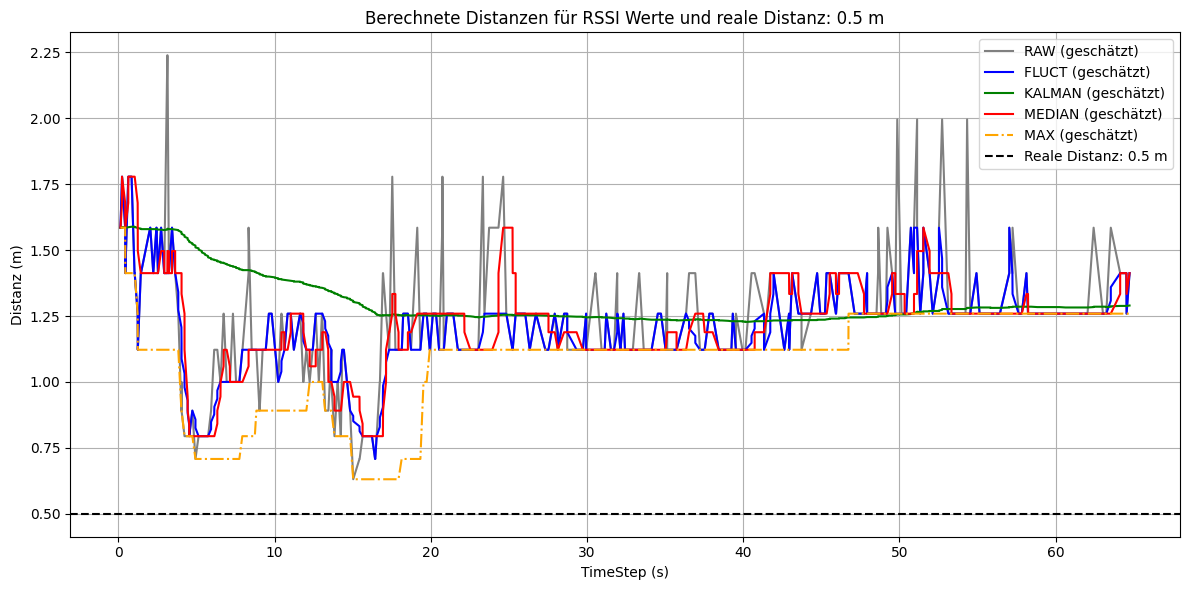

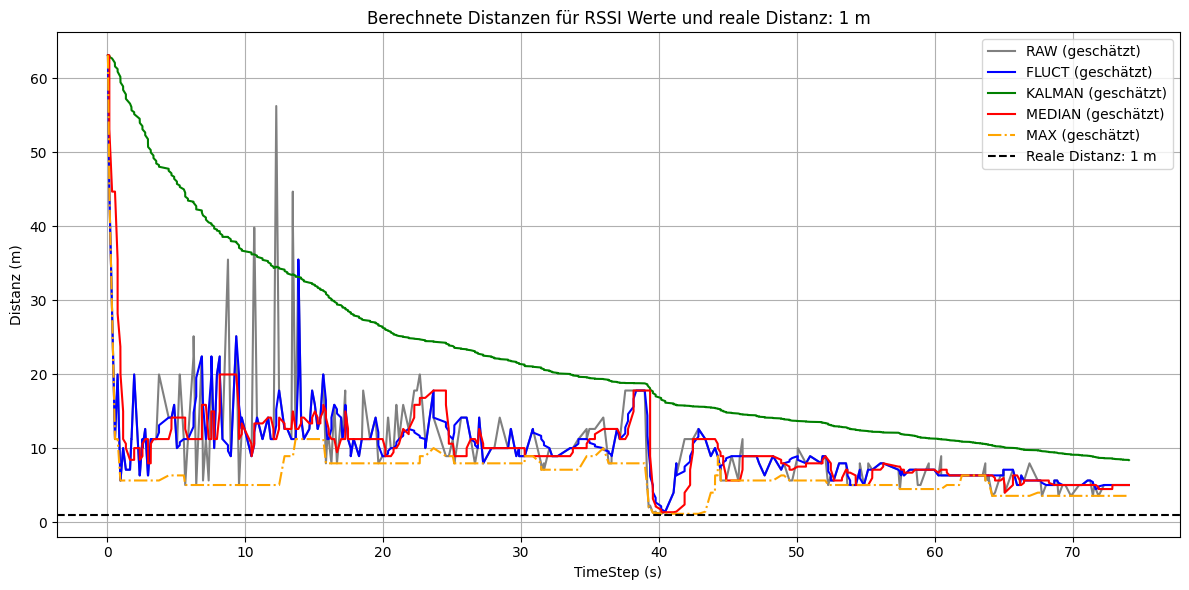

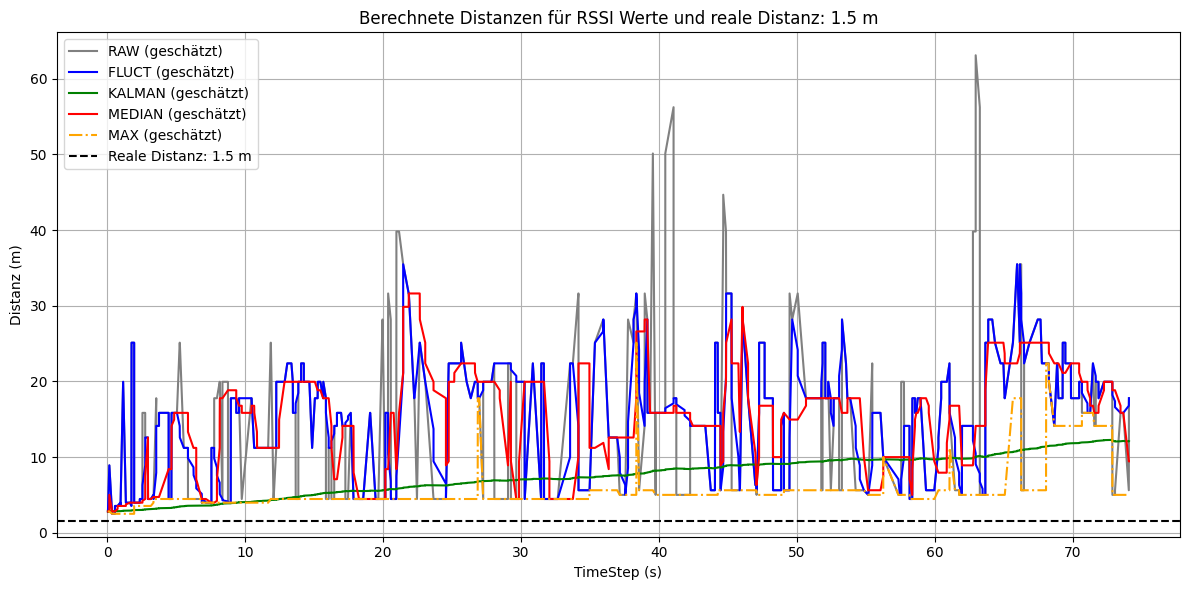

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Logarithmische Path Loss Funktion zur Berechnung der Distanz
def logarithmic_distance_path_loss(rssi, rssi_one_meter, disturbance_level):
    n = round(disturbance_level, 2)
    a = round(rssi_one_meter, 2)

    # Berechnung der Entfernung
    return 10**((a - rssi) / (10 * n))

# Parameter
rssi_one_meter = -40  # RSSI-Wert bei 1 Meter (dBm), anpassen
disturbance_level = 2.0  # Störungseffekt (Wert n, anpassen)

# Anzahl der Filter (RAW, FLUCT, KALMAN, MEDIAN, MAX)
num_filters = 5

# Variablen, um die berechneten Distanzen zu speichern
distances_estimated_all = {}
real_distances = []

# Durch alle Distanzen iterieren
for i, dist in enumerate(distances):
    real_distances.append(dist)

    # Spalten für die aktuelle Distanz extrahieren
    start_col = i * (num_filters + 1)  # Startspalte für diese Distanz
    cols = df.columns[start_col : start_col + (num_filters + 1)]  # Zeitsäule + Filterspalten

    # Sub-DataFrame erstellen
    dist_df = df[cols].rename(columns={
        cols[0]: 'TimeStep',
        cols[1]: 'RAW',
        cols[2]: 'FLUCT',
        cols[3]: 'KALMAN',
        cols[4]: 'MEDIAN',
        cols[5]: 'MAX'
    })

    # NaN-Werte interpolieren
    dist_df = dist_df.interpolate()

    # Berechnete Distanzen aus RSSI-Werten für jeden Filter
    distances_estimated = {
        'RAW': [],
        'FLUCT': [],
        'KALMAN': [],
        'MEDIAN': [],
        'MAX': []
    }

    # Berechnung der Distanzen für jedes Filter
    for filter_name in distances_estimated.keys():
        for rssi in dist_df[filter_name]:
            distance_est = logarithmic_distance_path_loss(rssi, rssi_one_meter, disturbance_level)
            distances_estimated[filter_name].append(distance_est)

    # Speichern der berechneten Distanzen für diese Distanz
    distances_estimated_all[dist] = distances_estimated

    # Plot für die aktuellen Distanzen erstellen
    plt.figure(figsize=(12, 6))

    # Plot der geschätzten Distanzen basierend auf den verschiedenen Filtern
    plt.plot(dist_df['TimeStep'], distances_estimated['RAW'], label='RAW (geschätzt)', color='gray', linestyle='-')
    plt.plot(dist_df['TimeStep'], distances_estimated['FLUCT'], label='FLUCT (geschätzt)', color='blue', linestyle='-')
    plt.plot(dist_df['TimeStep'], distances_estimated['KALMAN'], label='KALMAN (geschätzt)', color='green', linestyle='-')
    plt.plot(dist_df['TimeStep'], distances_estimated['MEDIAN'], label='MEDIAN (geschätzt)', color='red', linestyle='-')
    plt.plot(dist_df['TimeStep'], distances_estimated['MAX'], label='MAX (geschätzt)', color='orange', linestyle='-.')

    # Realen Distanz als Referenz einzeichnen
    plt.axhline(y=dist, color='black', linestyle='--', label=f'Reale Distanz: {dist} m')

    # Achsenbeschriftungen und Titel
    plt.ylabel('Distanz (m)')
    plt.xlabel('TimeStep (s)')
    plt.title(f'Berechnete Distanzen für RSSI Werte und reale Distanz: {dist} m')
    plt.legend()
    plt.grid()
    plt.tight_layout()

    # Diagramm anzeigen
    plt.show()


# 3.2 Fehlerplot als kumulative Verteilungsfunktion (CDF)

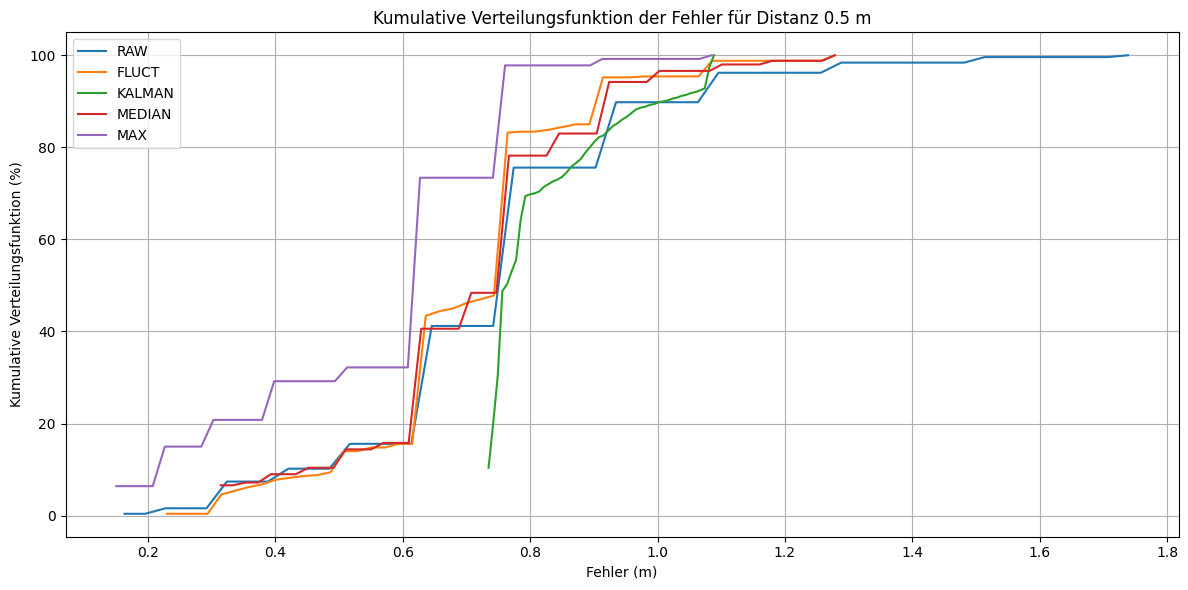

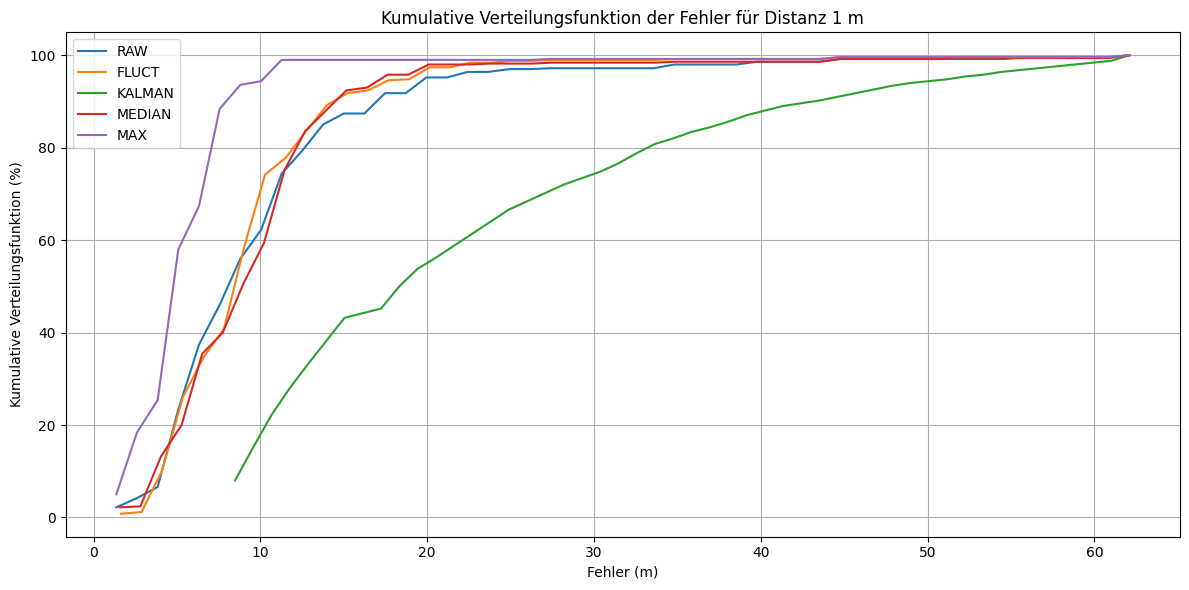

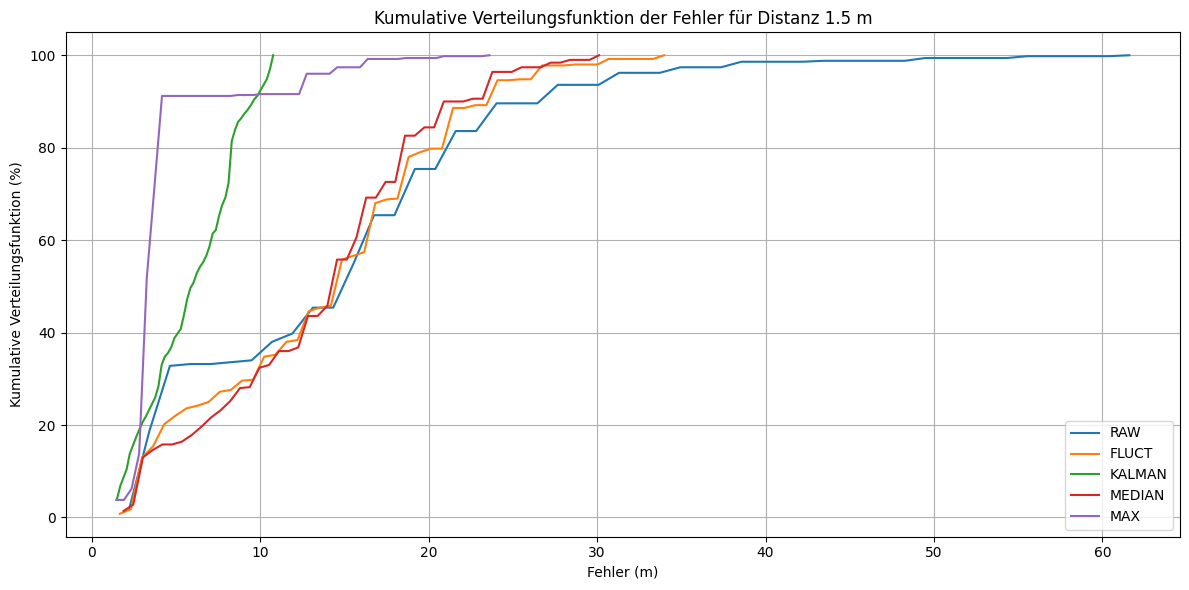

In [34]:
# Durch alle Distanzen iterieren und Fehler berechnen
for i, dist in enumerate(real_distances):
    distances_estimated = distances_estimated_all[dist]

    # Fehlerberechnung (Differenz zwischen realer und geschätzter Distanz)
    error_estimated = {
        'RAW': np.abs(np.array(distances_estimated['RAW']) - dist),
        'FLUCT': np.abs(np.array(distances_estimated['FLUCT']) - dist),
        'KALMAN': np.abs(np.array(distances_estimated['KALMAN']) - dist),
        'MEDIAN': np.abs(np.array(distances_estimated['MEDIAN']) - dist),
        'MAX': np.abs(np.array(distances_estimated['MAX']) - dist)
    }

    # Neuer Plot für jede Distanz
    plt.figure(figsize=(12, 6))

    # Für jeden Filter den Fehler als CDF plotten
    for filter_name, error in error_estimated.items():
        # Histogramm berechnen
        hist, bins = np.histogram(error, bins=50, density=True)
        cdf = np.cumsum(hist)  # Kumulative Summe (CDF)

        # Normalisieren der CDF auf 0%-100%
        cdf = cdf / cdf[-1] * 100

        # Plot der CDF
        plt.plot(bins[1:], cdf, label=f'{filter_name}')

    # Achsenbeschriftungen und Titel
    plt.xlabel('Fehler (m)')
    plt.ylabel('Kumulative Verteilungsfunktion (%)')
    plt.title(f'Kumulative Verteilungsfunktion der Fehler für Distanz {dist} m')
    plt.legend()
    plt.grid()

    # Layout anpassen
    plt.tight_layout()

    # Diagramm anzeigen
    plt.show()